# **RETENTION ENGINE + CUSTOMER RISK SEGMENTATION**

### Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

### Importing Dataset

In [2]:
df = pd.read_csv(
    '../data/processed/cleaned_churn.csv'
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


### Convert TotalCharges

In [3]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

### Remove missing values

In [4]:
df.dropna(inplace=True)

### Reset index

In [5]:
df.reset_index(drop=True, inplace=True)

### CUSTOMER HEALTH SCORE

In [6]:
def health_score(row):

    score = 100

    # New Customers
    if row['tenure'] < 12:
        score -= 30

    # High Monthly Charges
    if row['MonthlyCharges'] > 80:
        score -= 20

    # Risky Contract
    if row['Contract'] == 'Month-to-month':
        score -= 25

    # No Tech Support
    if row['TechSupport'] == 'No':
        score -= 10

    # Fiber Optic Dissatisfaction
    if row['InternetService'] == 'Fiber optic':
        score -= 10

    return score

# Apply Health Score
df['health_score'] = df.apply(
    health_score,
    axis=1
)

print("Customer Health Scores Generated")

Customer Health Scores Generated


### RISK SEGMENTATION

In [7]:
def risk_segment(score):

    if score < 40:
        return 'Critical Risk'

    elif score < 60:
        return 'High Risk'

    elif score < 80:
        return 'Medium Risk'

    return 'Low Risk'

# Apply Risk Segmentation
df['risk_segment'] = df['health_score'].apply(
    risk_segment
)

print("Risk Segmentation Completed")

Risk Segmentation Completed


### RETENTION RECOMMENDATION ENGINE

In [8]:
def recommendation(row):

    if row['risk_segment'] == 'Critical Risk':
        return 'Assign Relationship Manager'

    elif row['risk_segment'] == 'High Risk':
        return 'Provide Discount Offer'

    elif row['risk_segment'] == 'Medium Risk':
        return 'Send Engagement Campaign'

    return 'No Action Required'

# Apply Recommendations
df['recommended_action'] = df.apply(
    recommendation,
    axis=1
)

print("Retention Recommendations Generated")

Retention Recommendations Generated


### CUSTOMER SEGMENT SUMMARY

In [9]:
segment_summary = df.groupby(
    'risk_segment'
).agg({

    'customerID': 'count',
    'MonthlyCharges': 'mean',
    'TotalCharges': 'sum'

}).rename(columns={

    'customerID': 'total_customers',
    'MonthlyCharges': 'avg_monthly_charges',
    'TotalCharges': 'total_revenue'

})

print("\nCustomer Risk Summary:\n")

print(segment_summary)


Customer Risk Summary:

               total_customers  avg_monthly_charges  total_revenue
risk_segment                                                      
Critical Risk             2169            77.358207     2950637.45
High Risk                  996            57.235241     1408934.10
Low Risk                  2051            46.966285     4986629.45
Medium Risk               1816            74.084196     6709967.70


### HIGH RISK CUSTOMERS

In [10]:
high_risk_customers = df[

    df['risk_segment'].isin([
        'Critical Risk',
        'High Risk'
    ])

]

print("\nHigh Risk Customers:\n")

print(

    high_risk_customers[[
        'customerID',
        'tenure',
        'MonthlyCharges',
        'Contract',
        'risk_segment',
        'recommended_action'
    ]].head(10)

)


High Risk Customers:

    customerID  tenure  MonthlyCharges        Contract   risk_segment  \
0   7590-VHVEG       1           29.85  Month-to-month  Critical Risk   
2   3668-QPYBK       2           53.85  Month-to-month  Critical Risk   
4   9237-HQITU       2           70.70  Month-to-month  Critical Risk   
5   9305-CDSKC       8           99.65  Month-to-month  Critical Risk   
6   1452-KIOVK      22           89.10  Month-to-month  Critical Risk   
7   6713-OKOMC      10           29.75  Month-to-month  Critical Risk   
8   7892-POOKP      28          104.80  Month-to-month      High Risk   
13  0280-XJGEX      49          103.70  Month-to-month  Critical Risk   
14  5129-JLPIS      25          105.50  Month-to-month      High Risk   
18  4190-MFLUW      10           55.20  Month-to-month      High Risk   

             recommended_action  
0   Assign Relationship Manager  
2   Assign Relationship Manager  
4   Assign Relationship Manager  
5   Assign Relationship Manager  
6  

### RISK SEGMENT VISUALIZATION

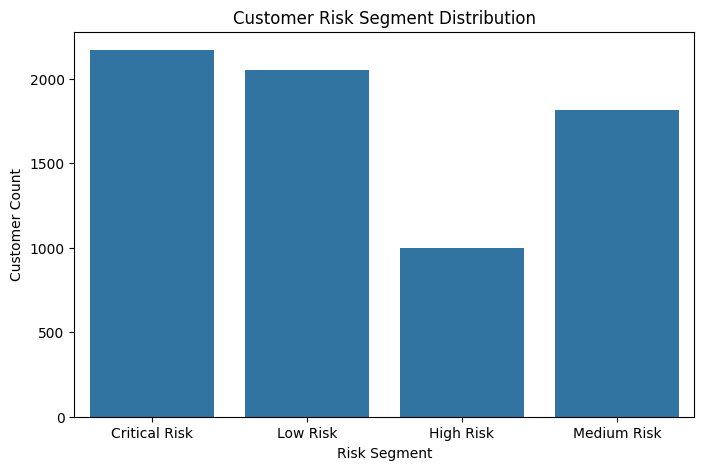

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='risk_segment',
    data=df
)
plt.title('Customer Risk Segment Distribution')
plt.xlabel('Risk Segment')
plt.ylabel('Customer Count')
plt.show()

### HEALTH SCORE DISTRIBUTION

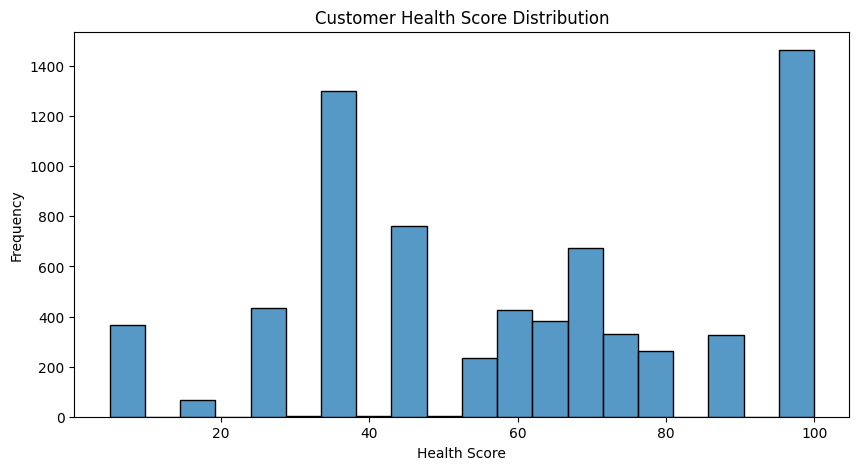

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(
    df['health_score'],
    bins=20
)
plt.title('Customer Health Score Distribution')
plt.xlabel('Health Score')
plt.ylabel('Frequency')
plt.show()

### RECOMMENDATION DISTRIBUTION

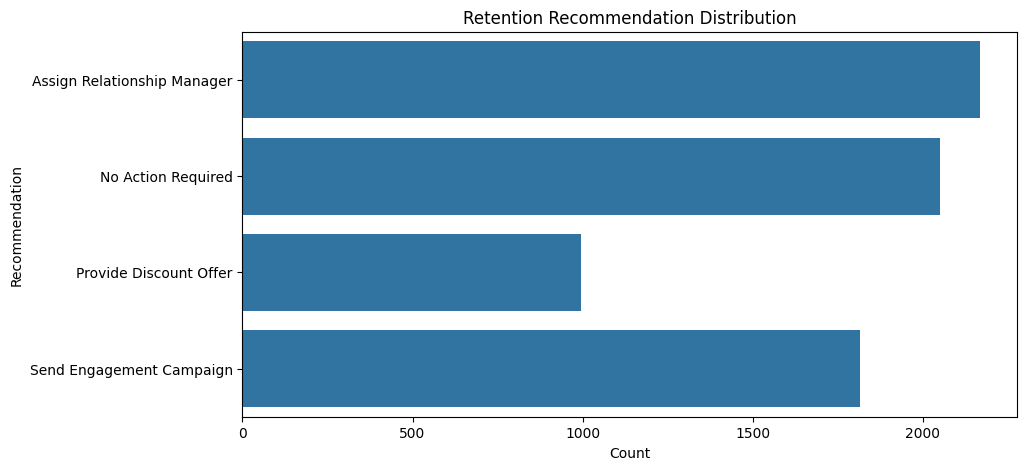

In [13]:
plt.figure(figsize=(10,5))
sns.countplot(
    y='recommended_action',
    data=df
)
plt.title('Retention Recommendation Distribution')
plt.xlabel('Count')
plt.ylabel('Recommendation')
plt.show()

### POTENTIAL REVENUE AT RISK

In [14]:
revenue_risk = df.groupby(
    'risk_segment'
)['MonthlyCharges'].sum()

print("\nPotential Revenue at Risk:\n")

print(revenue_risk)


Potential Revenue at Risk:

risk_segment
Critical Risk    167789.95
High Risk         57006.30
Low Risk          96327.85
Medium Risk      134536.90
Name: MonthlyCharges, dtype: float64


### SAVE FINAL DATASET

In [15]:
df.to_csv(
    '../data/processed/final_churn.csv',
    index=False
)

print("\nFinal Dataset Saved Successfully")


Final Dataset Saved Successfully


### EXPORT HIGH RISK CUSTOMERS

In [16]:
high_risk_customers.to_csv(
    '../data/processed/high_risk_customers.csv',
    index=False
)

print("High Risk Customer Report Exported")

High Risk Customer Report Exported


### FINAL PREVIEW

In [17]:
print("\nFinal Dataset Preview:\n")

print(df.head())


Final Dataset Preview:

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ...        Contract  \
0  No phone service             DSL             No  ...  Month-to-month   
1                No             DSL            Yes  ...        One year   
2                No             DSL            Yes  ...  Month-to-month   
3  No phone service             DSL            Yes  ...        One year   
4                No     Fiber optic             No  ...  Month-to-month   

  PaperlessBilling              PaymentMeth